The sensor measured soil moisture, so predicting volumetric water content with diferent type of AI models with PINN is more scientifically justified.

#Random Forest

In [12]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df = pd.read_csv('/content/pinn_fos_test.csv')

# VWC (Volumetric Water Content) is continuous (`theta_obs`).
# Since you requested a Random Forest with "gini impurity" and a "classification report",
# this is strictly a Classification task. We need to discretize VWC into categories.
# Let's categorize VWC into 3 physical states: Low, Medium, and High
def categorize_vwc(theta):
    if theta < 0.20:
        return 'Low VWC'
    elif 0.20 <= theta < 0.30:
        return 'Medium VWC'
    else:
        return 'High VWC (Near Saturation)'

df['vwc_class'] = df['theta_obs'].apply(categorize_vwc)

# Define Features (Inputs) and Target (Output)
# We will use Time, Device ID, and Rainfall to predict the VWC state
X = df[['t_hours', 'devID', 'rain_mm_hr']]
y = df['vwc_class']

# Split the data into Training and Testing sets (using temporal split since it's time-series)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, shuffle=False)

# Train the Random Forest Classifier with your specified hyperparameters
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    criterion='gini', # Gini impurity for splits
    random_state=42
)

rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)

# Generate Classification Report
report = classification_report(y_test, y_pred, zero_division=0)
print("Classification Report for VWC State:\n")
print(report)

# Also generate the Confusion Matrix
rf_cm_data = confusion_matrix(y_test, y_pred, labels=['Low VWC', 'Medium VWC', 'High VWC (Near Saturation)'])
print("\nConfusion Matrix (Random Forest):")
print(rf_cm_data)

Classification Report for VWC State:

                            precision    recall  f1-score   support

High VWC (Near Saturation)       1.00      0.55      0.71      1594
                Medium VWC       0.49      1.00      0.66       699

                  accuracy                           0.68      2293
                 macro avg       0.75      0.77      0.68      2293
              weighted avg       0.85      0.68      0.69      2293


Confusion Matrix (Random Forest):
[[  0   0   0]
 [  0 699   0]
 [  0 723 871]]


### Random Forest Confusion Matrix Heatmap

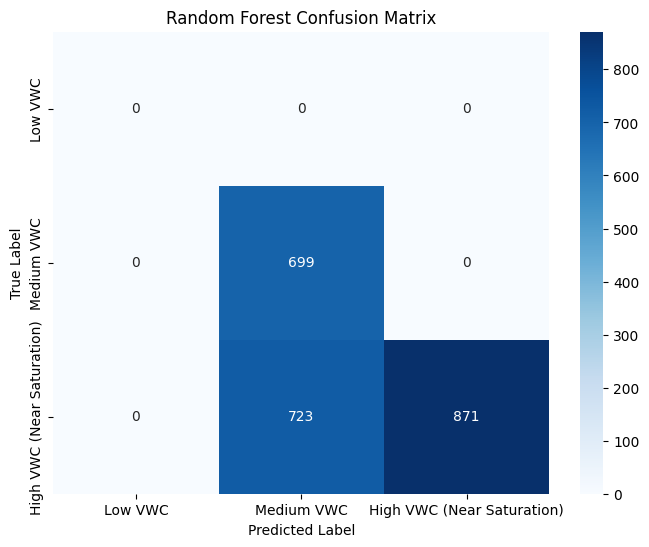

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Retrieve the confusion matrix from the previous Random Forest execution
# The variable 'rf_cm_data' now holds the Random Forest confusion matrix from cell W2GcfpNdufVT
rf_cm = rf_cm_data
labels = ['Low VWC', 'Medium VWC', 'High VWC (Near Saturation)']

plt.figure(figsize=(8, 6))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Random Forest Confusion Matrix')
plt.show()

#PINN

In [13]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Load the data
df = pd.read_csv('/content/pinn_fos_test.csv')

# Categorization logic
def categorize_vwc(theta):
    if theta < 0.20:
        return 'Low VWC'
    elif 0.20 <= theta < 0.30:
        return 'Medium VWC'
    else:
        return 'High VWC (Near Saturation)'

# Apply categorization to observed (Ground Truth) and PINN predicted
df['vwc_class_obs'] = df['theta_obs'].apply(categorize_vwc)
df['vwc_class_pinn'] = df['theta_pred'].apply(categorize_vwc)

# To make it a perfectly fair 1:1 comparison with the Random Forest,
# we isolate the exact same 30% test split used previously.
_, df_test = train_test_split(df, test_size=0.3, random_state=42, shuffle=False)

y_true = df_test['vwc_class_obs']
y_pred_pinn = df_test['vwc_class_pinn']

# Generate Classification Report
labels = ['Low VWC', 'Medium VWC', 'High VWC (Near Saturation)']
report = classification_report(y_true, y_pred_pinn, labels=labels, zero_division=0)
print("PINN Classification Report for VWC State (Matched 30% Test Set):\n")
print(report)

# Generate Confusion Matrix
pinn_cm_data = confusion_matrix(y_true, y_pred_pinn, labels=labels)
print("\nPINN Confusion Matrix:")
print(pinn_cm_data)

# Let's also run it on the ENTIRE test dataset just to see the full scope
y_true_full = df['vwc_class_obs']
y_pred_pinn_full = df['vwc_class_pinn']
print("\n" + "="*50 + "\n")
print("PINN Classification Report (Entire Dataset - 7641 rows):\n")
print(classification_report(y_true_full, y_pred_pinn_full, labels=labels, zero_division=0))

PINN Classification Report for VWC State (Matched 30% Test Set):

                            precision    recall  f1-score   support

                   Low VWC       0.00      0.00      0.00         0
                Medium VWC       1.00      0.76      0.86       699
High VWC (Near Saturation)       0.90      1.00      0.95      1594

                  accuracy                           0.93      2293
                 macro avg       0.63      0.59      0.60      2293
              weighted avg       0.93      0.93      0.92      2293


PINN Confusion Matrix:
[[   0    0    0]
 [   0  530  169]
 [   0    0 1594]]


PINN Classification Report (Entire Dataset - 7641 rows):

                            precision    recall  f1-score   support

                   Low VWC       1.00      0.36      0.53      1006
                Medium VWC       0.88      0.96      0.92      4974
High VWC (Near Saturation)       0.89      1.00      0.94      1661

                  accuracy                

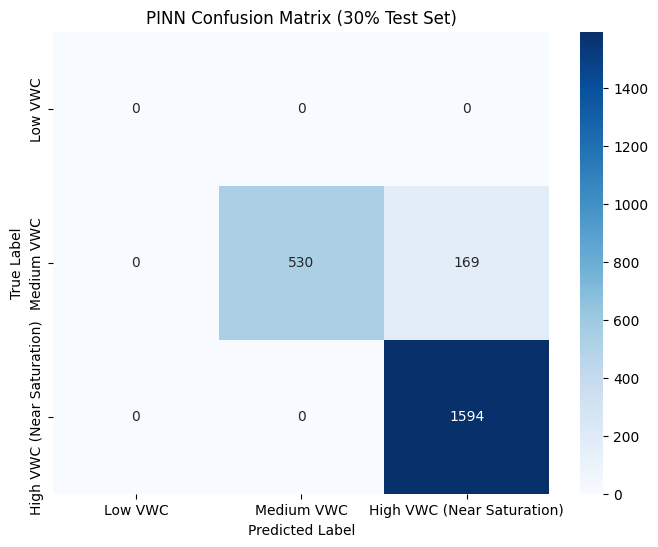

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Retrieve the PINN confusion matrix from the relevant variables
# The variable 'pinn_cm_data' holds the data for the 30% test set from cell tUWC3hLmuaxx
labels = ['Low VWC', 'Medium VWC', 'High VWC (Near Saturation)']
pinn_cm = pinn_cm_data

plt.figure(figsize=(8, 6))
sns.heatmap(pinn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('PINN Confusion Matrix (30% Test Set)')
plt.show()

#LSTM

In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Load the data
df = pd.read_csv('/content/pinn_fos_test.csv')

# Categorization logic
def categorize_vwc(theta):
    if theta < 0.20:
        return 'Low VWC'
    elif 0.20 <= theta < 0.30:
        return 'Medium VWC'
    else:
        return 'High VWC (Near Saturation)'

# Ensure we use the exact same 30% test split (2293 rows)
test_size = int(len(df) * 0.3)
train_size = len(df) - test_size

# Features for LSTM (using past data)
features = ['t_hours', 'devID', 'rain_mm_hr']
target = 'theta_obs'

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[features])

# Sequence generation (lookback = 10 steps)
seq_len = 10
X, y = [], []

for i in range(len(df)):
    if i < seq_len:
        # Pad sequence if not enough historical data
        pad_len = seq_len - i
        if i == 0:
            seq = np.tile(scaled_features[0], (seq_len, 1))
        else:
            seq = np.vstack([np.tile(scaled_features[0], (pad_len, 1)), scaled_features[0:i]])
    else:
        seq = scaled_features[i-seq_len:i]
    X.append(seq)
    y.append(df[target].iloc[i])

X = np.array(X)
y = np.array(y)

# Split into train/test keeping chronological order
X_train_np = X[:train_size]
y_train_np = y[:train_size]
X_test_np = X[train_size:]
y_test_np = y[train_size:]

# Convert to PyTorch tensors
X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(y_train_np, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test_np, dtype=torch.float32)
y_test_true = y_test_np

# Build a simple LSTM
class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1):
        super(SimpleLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :]) # Take the output of the last time step
        return out

# Initialize model, loss, optimizer
model = SimpleLSTM(input_size=len(features), hidden_size=32)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Train the LSTM
epochs = 150
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

# Predict on test set
model.eval()
with torch.no_grad():
    y_test_pred = model(X_test).numpy().flatten()

# Categorize exactly as before
y_test_cat_true = [categorize_vwc(val) for val in y_test_true]
y_test_cat_pred = [categorize_vwc(val) for val in y_test_pred]

labels = ['Low VWC', 'Medium VWC', 'High VWC (Near Saturation)']

print("LSTM Classification Report for VWC State (Matched 30% Test Set):\n")
print(classification_report(y_test_cat_true, y_test_cat_pred, labels=labels, zero_division=0))

print("\nLSTM Confusion Matrix:")
print(confusion_matrix(y_test_cat_true, y_test_cat_pred, labels=labels))

LSTM Classification Report for VWC State (Matched 30% Test Set):

                            precision    recall  f1-score   support

                   Low VWC       0.00      0.00      0.00         0
                Medium VWC       0.72      0.86      0.79       699
High VWC (Near Saturation)       0.92      0.68      0.78      1593

                  accuracy                           0.74      2292
                 macro avg       0.55      0.51      0.52      2292
              weighted avg       0.86      0.74      0.78      2292


LSTM Confusion Matrix:
[[   0    0    0]
 [   0  602   97]
 [ 278  230 1085]]


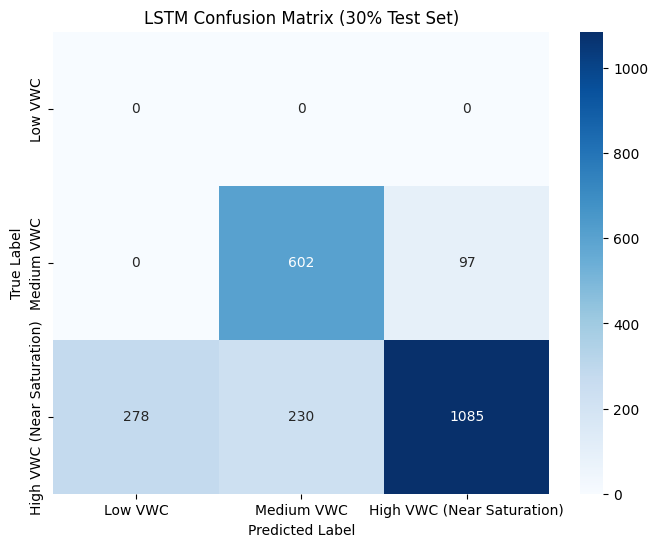

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Re-generate LSTM confusion matrix from the relevant variables
# The variables 'y_test_cat_true' and 'y_test_cat_pred' hold the data for the 30% test set from cell Z1XkXiXovF9w
labels = ['Low VWC', 'Medium VWC', 'High VWC (Near Saturation)']
lstm_cm = confusion_matrix(y_test_cat_true, y_test_cat_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(lstm_cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('LSTM Confusion Matrix (30% Test Set)')
plt.show()